In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

<h1>Data Extraction</h1>

In [3]:
import csv

path = "data/possum.csv"

with open(path, mode="r", encoding="utf-8") as file:
    csv_reader = csv.reader(file)
    header = next(csv_reader)
    rows = list(csv_reader)
df = pd.DataFrame(rows, columns=header)

numeric_cols = ["site", "age", "hdlngth", "skullw", "totlngth", "taill"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(f"Loaded {len(df)} rows. Shape: {df.shape}")

Loaded 104 rows. Shape: (104, 14)


<h1>Data Cleaning</h1>

In [4]:
column_drop = ["case", "site", "Pop"]

df = df.drop(columns=[col for col in column_drop if col in df.columns])

In [5]:
df.dropna(inplace=True)
df.isnull().sum()

sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [6]:
df["sex_encoded"] = df["sex"].map({"m": 0, "f": 1})

<h1>Data Analytics</h1>

In [7]:
target_cols = {
    "sex_encoded" : "red",
    "age" : "orange",
    "hdlngth" : "blue"
}
col_names = ["Sex", "Age", "Head Length"]

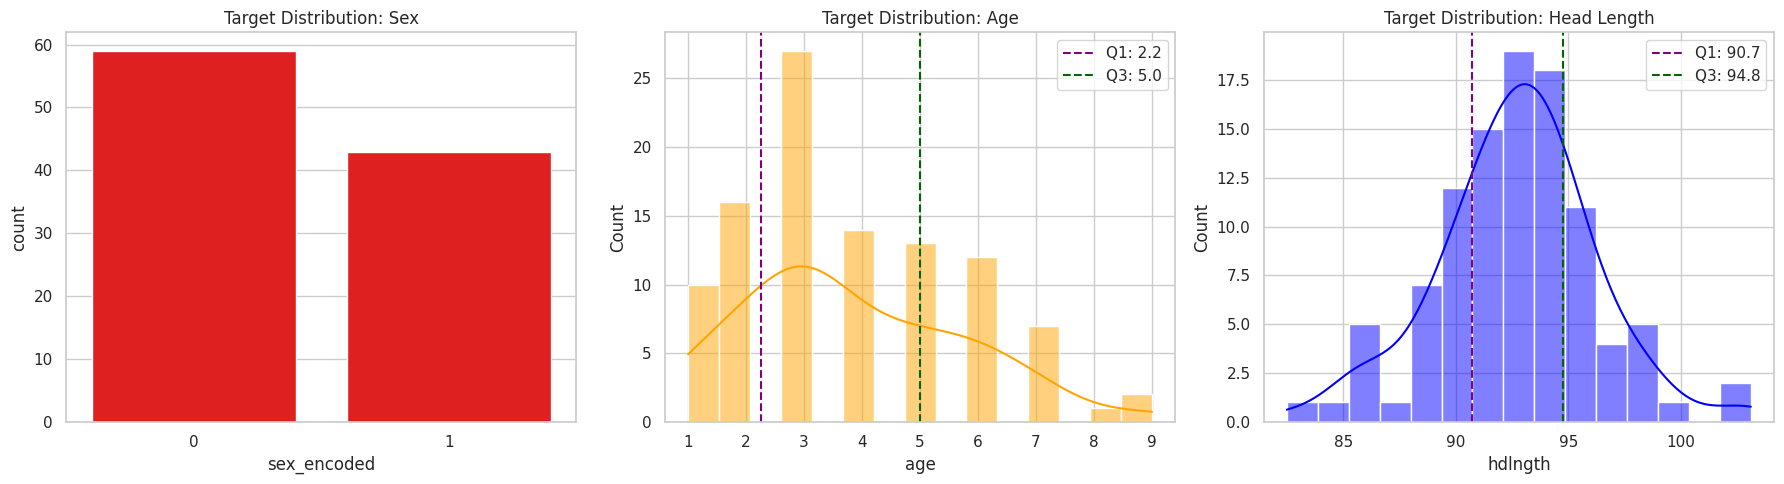

In [9]:
cols_grid = 4
rows_grid = 4

fig, axes = plt.subplots(1, len(target_cols), figsize=(18, 5))

for i, (col_name, col_color) in enumerate(target_cols.items()):
    if col_name not in df.columns:
        continue

    if col_name == "sex_encoded":
        sns.countplot(
            data=df,
            x=col_name,
            color=col_color,
            ax=axes[i]
        )

    else:
        q1_val = df[col_name].quantile(0.25)
        q3_val = df[col_name].quantile(0.75)

        sns.histplot(
            data=df,
            x=col_name,
            bins=15,
            kde=True,
            color=col_color,
            ax=axes[i]
        )

        axes[i].axvline(x=q1_val, color="purple", linestyle="--", linewidth=1.5, label=f"Q1: {q1_val:.1f}")
        axes[i].axvline(x=q3_val, color="darkgreen", linestyle="--", linewidth=1.5, label=f"Q3: {q3_val:.1f}")
        axes[i].legend()

    axes[i].set_title(f"Target Distribution: {col_names[i]}")
    axes[i].set_xlabel(col_name)

plt.tight_layout()
plt.show()

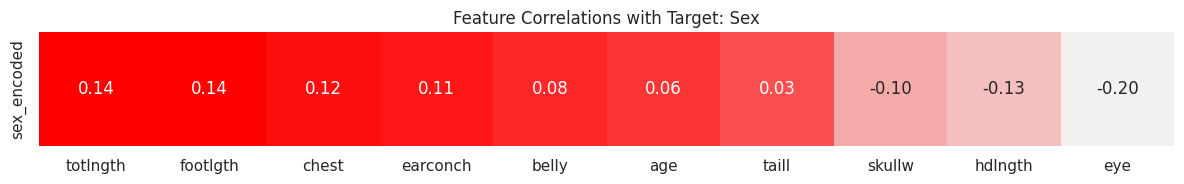

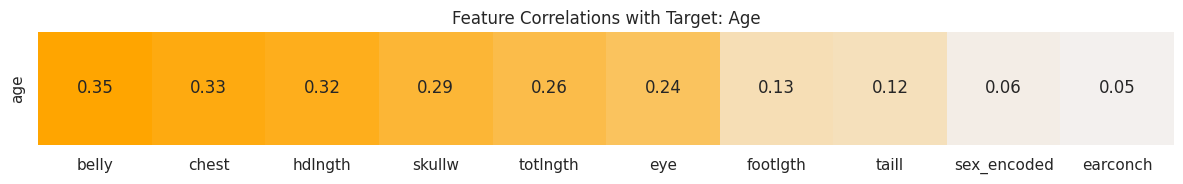

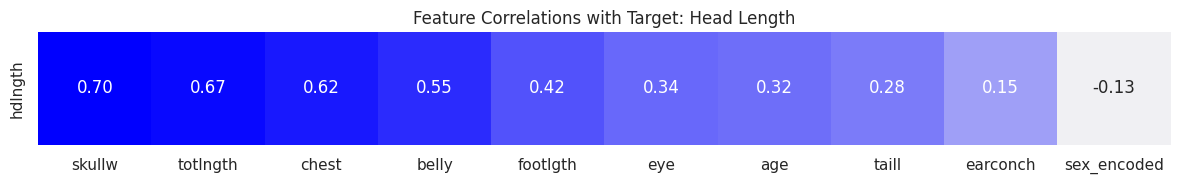

In [10]:
relation_features = ["skullw", "totlngth", "taill", "footlgth", "earconch", "eye", "chest", "belly"]
active_target = list(target_cols.keys())
all_col = list(set(relation_features + active_target))
col_names = ["Sex", "Age", "Head Length"]

corr_df = df[all_col].apply(pd.to_numeric, errors="coerce")
full_corr_matrix = corr_df.corr()

for i, (col_name, col_color) in enumerate(target_cols.items()):
    if col_name not in full_corr_matrix.columns:
        continue
        
    plt.figure(figsize=(12, 2))

    target_vector = full_corr_matrix[[col_name]].drop(index=col_name).sort_values(by=col_name, ascending=False)

    sns.heatmap(
        target_vector.T, 
        annot=True, 
        fmt=".2f", 
        cmap=sns.light_palette(col_color, as_cmap=True),
        cbar=False
    )
    plt.title(f"Feature Correlations with Target: {col_names[i]}")
    plt.tight_layout()
    plt.show()

<h1>Phenomenon</h1>
<h3>Distribution chart</h3>
<ul>
    <li>Sex: Biased towards male possums</li>
    <li>Age: Right-skewed with higher distribution of younger possums</li>
    <li>Head length: Symmetrically skewed, centered between 90.7mm and 94.8mm</li>
</ul>
<h3>Relational Heatmap</h3>
<ul>
    <li>Sex: Weak correlation with other features (0.14 to -0.2)</li>
    <li>Age: Moderate correlation with other features (0.35 to 0.05)</li>
    <li>Head length: Strong and wide-ranged correlation with other features (0.70 to -0.13)</li>
</ul>